# Really simple pre-trained ASL model adapter architecture:
```
audio
 ↓
cochleagram (your auditory model)
 ↓
adapter network  ← you train this
 ↓
Whisper input features (log-mel)
 ↓
Whisper model (encoder + decoder)
 ↓
text
```
$$
G(C_{\text{bad}})\approx M
$$
- $C_{bad} = \text{chocheagram}$
- $M = $ Whisper input features (log-mel)
- $G$ is the adapter network that maps from the degraded cochleagram to the Whisper input features.

### Imports and Data loading

In [2]:
import numpy as np
import librosa
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve, hilbert

from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split

y, fs = librosa.load("../KU.wav", sr=None)
print("Original fs:", fs)

target_fs = 16000
if fs != target_fs:
    y = librosa.resample(y, orig_sr=fs, target_sr=target_fs)
    fs = target_fs

y = y / (np.max(np.abs(y)) + 1e-9)
print("Using fs:", fs, "| samples:", len(y))

c:\Users\tonyt\Desktop\coch\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Original fs: 44100
Using fs: 16000 | samples: 2563855


### ERB helper functions (Hz ↔ ERB + centers)

In [3]:
def erb_hz(f):
    return 24.7 * (4.37 * f / 1000 + 1)

def erb_scale(f):
    return 21.4 * np.log10(1 + 0.00437 * f)

def inv_erb(e):
    return (10**(e / 21.4) - 1) / 0.00437

def erb_centers(fmin, fmax, n):
    e = np.linspace(erb_scale(fmin), erb_scale(fmax), n)
    return inv_erb(e)

### Gammatone impulse response

In [4]:
def gammatone(fs, fc, n=4, dur=0.08, bw_mult=1.0):
    t = np.arange(0, int(dur * fs)) / fs
    b = bw_mult * 1.019 * erb_hz(fc)
    g = t**(n - 1) * np.exp(-2 * np.pi * b * t) * np.cos(2 * np.pi * fc * t)
    g = g / (np.sqrt(np.sum(g**2)) + 1e-12)
    return g

### Cochleagram builder (band × frames)

In [5]:
def build_cochleagram(
    y, fs,
    fmin=100, fmax=10000,
    N=32,
    bw_mult=1.0,
    hop_ms=10
):
    hop = int((hop_ms / 1000) * fs)
    centers = erb_centers(fmin, fmax, N)

    bands = []
    for fc in centers:
        g = gammatone(fs, fc, bw_mult=bw_mult)
        y_filt = fftconvolve(y, g, mode="same")
        env = np.abs(hilbert(y_filt))
        env = np.log1p(env)         
        env_frames = env[::hop]   
        bands.append(env_frames)

    C = np.vstack(bands)        
    return C, centers, hop

# Run it

In [6]:
# Source ear (worse)
src = dict(N=19, bw_mult=3.0)

# Target ear (better / different)
tgt = dict(N=32, bw_mult=1.0) # "Normal-ish"
# tgt = dict(N=28, bw_mult=2.0) # "Moderate"
# tgt = dict(N=36, bw_mult=1.5) # "Mild-ish"

C_src, centers_src, hop = build_cochleagram(y, fs, N=src["N"], bw_mult=src["bw_mult"], hop_ms=10)
C_tgt, centers_tgt, _   = build_cochleagram(y, fs, N=tgt["N"], bw_mult=tgt["bw_mult"], hop_ms=10)

T = min(C_src.shape[1], C_tgt.shape[1])
C_src = C_src[:, :T]
C_tgt = C_tgt[:, :T]

print("C_src:", C_src.shape, "| C_tgt:", C_tgt.shape, "| hop(samples):", hop)

C_src: (19, 16025) | C_tgt: (32, 16025) | hop(samples): 160


# Turning the cochleargram into actual training data

In [7]:
# X: (T, N_src), Y: (T, N_tgt)
X = C_src.T
Y = C_tgt.T

# Standardize
X_mu, X_sd = X.mean(axis=0, keepdims=True), X.std(axis=0, keepdims=True) + 1e-8
Y_mu, Y_sd = Y.mean(axis=0, keepdims=True), Y.std(axis=0, keepdims=True) + 1e-8

Xz = (X - X_mu) / X_sd
Yz = (Y - Y_mu) / Y_sd

print("Xz:", Xz.shape, "| Yz:", Yz.shape)

Xz: (16025, 19) | Yz: (16025, 32)


### The fun model building stuff
Fitting a Ridged mapping $C_{src}(t) \to C_{target}$

In [8]:
T = Xz.shape[0]
cut = int(0.8 * T)

Xtr, Ytr = Xz[:cut], Yz[:cut]
Xte, Yte = Xz[cut:], Yz[cut:]

model = Ridge(alpha=1.0).fit(Xtr, Ytr)
Yhat_te = model.predict(Xte)
mae_te = np.mean(np.abs((Yhat_te * Y_sd + Y_mu) - (Yte * Y_sd + Y_mu)))
print("Block-heldout MAE:", mae_te)


# Predict all frames
Yhat_z = model.predict(Xz)
Yhat = Yhat_z * Y_sd + Y_mu
C_hat = Yhat.T #(N_tgt, T)


Block-heldout MAE: 0.0565631930316231


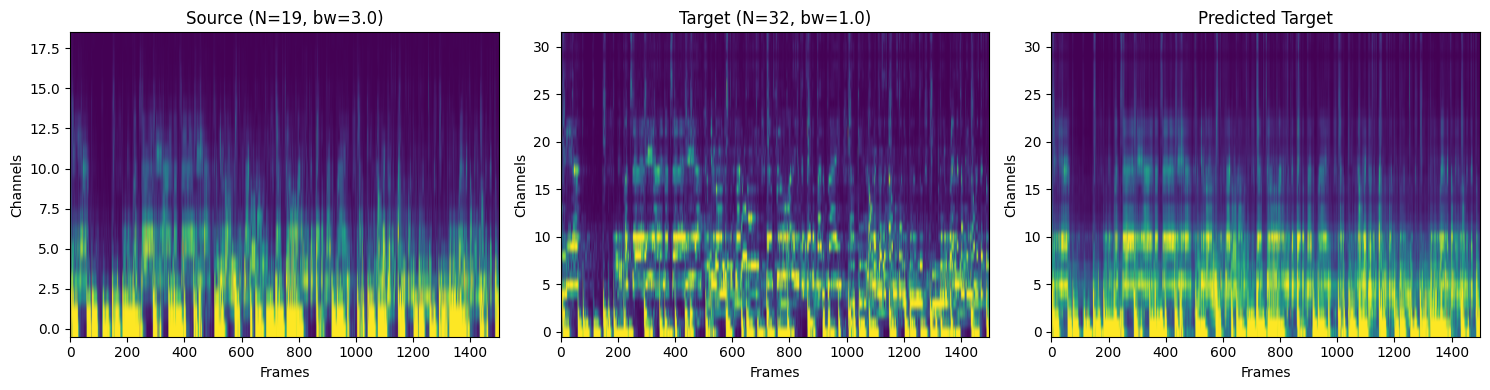

In [9]:
def show_triplet(C_src, C_tgt, C_hat, fs, hop, t0=30, t1=45):
    i0 = int((t0 * fs) / hop)
    i1 = int((t1 * fs) / hop)

    def im(ax, C, title):
        vmin = np.percentile(C, 5)
        vmax = np.percentile(C, 95)
        ax.imshow(C[:, i0:i1], aspect="auto", origin="lower", vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.set_xlabel("Frames")
        ax.set_ylabel("Channels")

    fig, axs = plt.subplots(1, 3, figsize=(15, 4))
    im(axs[0], C_src, f"Source (N={C_src.shape[0]}, bw={src['bw_mult']})")
    im(axs[1], C_tgt, f"Target (N={C_tgt.shape[0]}, bw={tgt['bw_mult']})")
    im(axs[2], C_hat, "Predicted Target")
    plt.tight_layout()
    plt.show()

show_triplet(C_src, C_tgt, C_hat, fs, hop, t0=30, t1=45)

#### Energy Profile

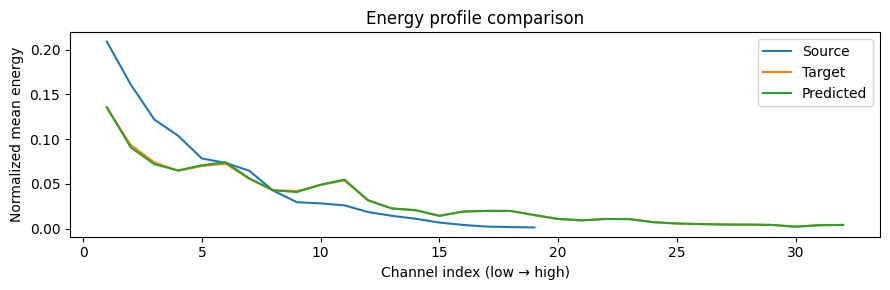

mean( predicted response - good ear response) = 0.07363116767501152


In [10]:
from IPython.display import  display, Markdown, HTML


def energy_profile(C):
    E = C.mean(axis=1)
    return E / (E.sum() + 1e-12)

E_src = energy_profile(C_src)
E_tgt = energy_profile(C_tgt)
E_hat = energy_profile(C_hat)

plt.figure(figsize=(9,3))
plt.plot(np.arange(1, len(E_src)+1), E_src, label="Source")
plt.plot(np.arange(1, len(E_tgt)+1), E_tgt, label="Target")
plt.plot(np.arange(1, len(E_hat)+1), E_hat, label="Predicted")
plt.xlabel("Channel index (low → high)")
plt.ylabel("Normalized mean energy")
plt.title("Energy profile comparison")
plt.legend()
plt.tight_layout()
plt.show()

print("mean( predicted response - good ear response) =", np.mean(np.abs(C_hat - C_tgt))) # 0.07285843590670384 So Target \approx Predicted

In [11]:
print("E_src:", E_src.shape)
print("E_tgt:", E_tgt.shape)
print("E_hat:", E_hat.shape)

print("Max difference Target vs Predicted:",
      np.max(np.abs(E_hat - E_tgt)))

E_src: (19,)
E_tgt: (32,)
E_hat: (32,)
Max difference Target vs Predicted: 0.0025856603193123856


# The goal
Really simply, the forward pipline is:
input: `speech.wav`

We know that:
$$
C_{\text{bad}} \to C_{\text{good}}
$$
is possible with small loss in structure due to the time dependencies.
### Uncovering speech
We want pass `speech.wav` into our cochleagram model to generate $C_{\text{bad}}$ and learn the structure of $C_{\text{good}}$.

Using Whisper (pre-trained LLM by OpenAi), we can identify the label of `speech.wav`.
1. Our new input $C_{\text{good}}(t_{i:j}) \to M$: whisper log-mel features. Passed into Whisper to generate Real sentence, we go A->B by learning the log-mel spectrogram representation.
2. On the other hand, we have $C_{\text{bad} \to \text{grid-space of good }}(t_{i:j}) \to \text{interpreted sentences}$
3. Get an error term by comparing differences

### What needs to be done first
How do we translate English into Spanish? I mean, cochleagram into log-mel (80 filters).
Once we train a model to do so, we can then:
```
C_bad → adapter → Whisper
C_corr → adapter → Whisper
```



| Mapping                             | Purpose                                | Relation                                             |
| ----------------------------------- | -------------------------------------- | -----------------------------------------------------|
| $C_{\text{bad}}\to C_{\text{good}}$ | Auditory correction                    | Local linear de-smearing                             |
| $C_{\text{good}}\to M$              | Feature translation into Whisper Space | Unknown non-linear transform by Whisper's preprocess |


In [12]:
# Adding the speech.wav file
import numpy as np
import torch
from datasets import load_dataset
from transformers import WhisperProcessor, WhisperForConditionalGeneration
from jiwer import wer

device = "cuda" if torch.cuda.is_available() else "cpu"
model_id = "openai/whisper-base"

processor = WhisperProcessor.from_pretrained(model_id)
model = WhisperForConditionalGeneration.from_pretrained(model_id).to(device)
model.eval()

ds = load_dataset("openslr/librispeech_asr", "clean", split="validation") 
"""
{
 "audio": {
   "array": waveform data,
   "sampling_rate": 16000
 },
 "text": "THE CAT SAT ON THE MAT"
}
"""
# take a few samples
ds_small = ds.select(range(10))

refs, hyps = [], []

for ex in ds_small:
    audio = ex["audio"]["array"]
    sr = ex["audio"]["sampling_rate"]
    ref = ex["text"]

    inputs = processor(audio, sampling_rate=sr, return_tensors="pt")
    input_features = inputs.input_features.to(device)

    with torch.no_grad():
        pred_ids = model.generate(input_features)
    hyp = processor.batch_decode(pred_ids, skip_special_tokens=True)[0]

    refs.append(ref.lower())
    hyps.append(hyp.lower())

print("Sample WER:", wer(refs, hyps))
print("Example:")
print("REF:", refs[0])
print("HYP:", hyps[0])

c:\Users\tonyt\Desktop\coch\.venv\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\tonyt\.cache\huggingface\hub\models--openai--whisper-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 245/245 [00:00<00:00, 5686.29it/s]
c:\Users\tonyt\Desktop\coch\.venv\Lib\site-pac

Sample WER: 0.13953488372093023
Example:
REF: he was in a fevered state of mind owing to the blight his wife's action threatened to cast upon his entire future
HYP:  he was in a fevered state of mind, owing to the blight his wife's action threatened to cast up on his entire future.


# Helper

In [13]:
import re
from jiwer import wer

def clean_text(s: str) -> str:
    s = s.lower()
    s = re.sub(r"[^\w\s]", "", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

@torch.no_grad()
def whisper_transcribe_from_audio(audio, sr, processor, model, device):
    inputs = processor(audio, sampling_rate=sr, return_tensors="pt")
    feats = inputs.input_features.to(device)  # (1, 80, T)
    pred_ids = model.generate(feats)
    hyp = processor.batch_decode(pred_ids, skip_special_tokens=True)[0]
    return hyp

In [58]:
import numpy as np
import torch
from transformers import WhisperProcessor
from sklearn.linear_model import Ridge

# Whisper constants
WHISPER_SR = 16000
HOP = 160                 # 10ms at 16kHz
N_FRAMES = 3000           # 30s * 100 fps

#processor = WhisperProcessor.from_pretrained("openai/whisper-base")

def whisper_feats_80x3000(audio_np, sr):
    """
    Returns:
      M: (80, 3000) torch float32
      n_valid: number of real (non-padded) frames
    """
    # Whisper expects 16k; LibriSpeech is already 16k but keep it general
    if sr != WHISPER_SR:
        import librosa
        audio_np = librosa.resample(audio_np, orig_sr=sr, target_sr=WHISPER_SR)
        sr = WHISPER_SR

    inputs = processor(audio_np, sampling_rate=sr, return_tensors="pt")  # pads/truncs to 30s
    M = inputs.input_features.squeeze(0)  # (80, 3000) by design

    # valid frames from true audio length (cap at 3000)
    n_valid = min(int(len(audio_np) // HOP), N_FRAMES)
    return M, n_valid

# def pad_or_trunc_C(C_32xT):
#     """
#     C: (32, T) -> (32, 3000)
#     """
#     C2 = np.zeros((C_32xT.shape[0], N_FRAMES), dtype=np.float32)
#     T = min(C_32xT.shape[1], N_FRAMES)
#     C2[:, :T] = C_32xT[:, :T]
#     return C2, T


def pad_or_trunc_C(C):
    C2 = np.zeros((C.shape[0], N_FRAMES), dtype=np.float32)
    T = min(C.shape[1], N_FRAMES)
    C2[:, :T] = C[:, :T]
    if T < N_FRAMES:
        mu = C[:, :T].mean(axis=1, keepdims=True)
        C2[:, T:] = mu
    return C2, T

run Whisper from features

In [75]:
@torch.no_grad()
def whisper_from_features(M_80x3000, processor, model, device):
    if isinstance(M_80x3000, np.ndarray):
        feats = torch.tensor(M_80x3000, dtype=torch.float32)
    else:
        feats = M_80x3000.float()

    # feats: (80, 3000) -> (1, 80, 3000)
    feats = feats.unsqueeze(0).to(device)

    pred_ids = model.generate(input_features=feats)   # <-- key fix
    return processor.batch_decode(pred_ids, skip_special_tokens=True)[0]

interpret bands bad to good

In [27]:
from scipy.interpolate import interp1d

def interp_src_to_tgt(C_src, centers_src, centers_tgt):
    f = interp1d(centers_src, C_src, axis=0, kind="linear", fill_value="extrapolate")
    return f(centers_tgt)

### Get traininng data

In [80]:
from datasets import load_dataset

ds = load_dataset("openslr/librispeech_asr", "clean", split="validation")
ds_small = ds.select(range(200))  # start small

# Split by clip (not by frames)
cut = int(0.8 * len(ds_small))
train_ex = ds_small.select(range(cut))
test_ex  = ds_small.select(range(cut, len(ds_small)))

X_list, Y_list = [], []
X_list, Y_list = [], []

for ex in train_ex:
    audio = ex["audio"]["array"]
    sr = ex["audio"]["sampling_rate"]
    if sr != 16000:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=16000)
        sr = 16000

    # Whisper target features
    M, n_valid = whisper_feats_80x3000(audio, sr)  # (80,3000)
    M = M.numpy()

    # Good cochleagram (32)
    C_good, centers_good, _ = build_cochleagram(audio, sr, N=32, bw_mult=1.0, hop_ms=10)

    # Bad cochleagram (19) -> align to 32
    C_bad, centers_bad, _ = build_cochleagram(audio, sr, N=19, bw_mult=3.0, hop_ms=10)
    C_bad_aligned = interp_src_to_tgt(C_bad, centers_bad, centers_good)

    # time crop to valid frames (no padding used for training)
    Tg = C_good.shape[1]
    Tb = C_bad_aligned.shape[1]
    n = min(n_valid, Tg, Tb)

    # stack both domains
    X_list.append(C_good[:, :n].T)        # (n,32)
    Y_list.append(M[:, :n].T)             # (n,80)

    X_list.append(C_bad_aligned[:, :n].T) # (n,32)
    Y_list.append(M[:, :n].T)             # (n,80)

X = np.vstack(X_list)
Y = np.vstack(Y_list)
print("X:", X.shape, "Y:", Y.shape)

X: (181388, 32) Y: (181388, 80)


Fitting bridge

In [81]:
from sklearn.linear_model import Ridge

bridge_X_mu = X.mean(axis=0, keepdims=True)
bridge_X_sd = X.std(axis=0, keepdims=True) + 1e-8

Xb = (X - bridge_X_mu) / bridge_X_sd

bridge = Ridge(alpha=5.0).fit(Xb, Y)
print("bridge trained (standardized inputs).")

bridge trained (standardized inputs).


In [60]:
ex = test_ex[0]
audio = ex["audio"]["array"]
sr = ex["audio"]["sampling_rate"]

M, n_valid = whisper_feats_80x3000(audio, sr)  # (80,3000), n_valid
C_good, _, _ = build_cochleagram(audio, 16000, N=32, bw_mult=1.0, hop_ms=10)

C_good_fixed, Tcg = pad_or_trunc_C(C_good)
n = min(n_valid, Tcg)

Yhat = bridge.predict(C_good_fixed[:, :n].T)  # (n,80)

mae = np.mean(np.abs(Yhat - M[:, :n].T.numpy()))
print("Bridge MAE on one held-out clip:", mae)

Bridge MAE on one held-out clip: 0.29827905


# Corrected aud

In [97]:
X_list, Y_list = [], []

for ex in train_ex:
    audio = ex["audio"]["array"]
    sr = ex["audio"]["sampling_rate"]
    if sr != 16000:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=16000)
        sr = 16000

    # target whisper log-mel
    M, n_valid = whisper_feats_80x3000(audio, sr)  # (80,3000)
    M = M.numpy()

    # bad cochleagram (19)
    C_bad, centers_bad, _ = build_cochleagram(audio, sr, N=19, bw_mult=3.0, hop_ms=10)

    # make 32-grid (centers) and align bad→32
    _, centers_32, _ = build_cochleagram(audio, sr, N=32, bw_mult=1.0, hop_ms=10)
    C_bad_32 = interp_src_to_tgt(C_bad, centers_bad, centers_32)

    T = min(n_valid, C_bad_32.shape[1])
    X_list.append(C_bad_32[:, :T].T)   # (T,32)
    Y_list.append(M[:, :T].T)          # (T,80)

X = np.vstack(X_list)
Y = np.vstack(Y_list)
print("Train:", X.shape, Y.shape)

Train: (90694, 32) (90694, 80)


### Fitting corrected model

In [ ]:
# # Build training matrices
# X_bad = np.vstack(X_list)   # (frames, 32)
# Y_good = np.vstack(Y_list)  # (frames, 32)

# # Standardize using TRAIN stats
# aud_X_mu = X_bad.mean(axis=0, keepdims=True)
# aud_X_sd = X_bad.std(axis=0, keepdims=True) + 1e-8
# aud_Y_mu = Y_good.mean(axis=0, keepdims=True)
# aud_Y_sd = Y_good.std(axis=0, keepdims=True) + 1e-8

# Xz = (X_bad - aud_X_mu) / aud_X_sd
# Yz = (Y_good - aud_Y_mu) / aud_Y_sd

# aud_model = Ridge(alpha=1.0).fit(Xz, Yz)
# print("aud_model trained (standardized).")
# """
# aud_model : 32 → 32
# bridge    : 32 → 80
# """

# def aud_correct(C_bad_aligned_32xT):
#     X = C_bad_aligned_32xT.T  # (T,32)
#     Xz = (X - aud_X_mu) / aud_X_sd
#     Yz_hat = aud_model.predict(Xz)
#     Y_hat = Yz_hat * aud_Y_sd + aud_Y_mu
#     return Y_hat.T  # (32,T)


bridge_X_mu = X.mean(axis=0, keepdims=True)
bridge_X_sd = X.std(axis=0, keepdims=True) + 1e-8
Xz = (X - bridge_X_mu) / bridge_X_sd

bridge = Ridge(alpha=10.0).fit(Xz, Y)

bridge trained: (90694, 32) → (90694, 80)


Compare 3 transcripts on one clip

normal Whisper features (ground truth features)

bridged from good cochleagram

later: bridged from corrected cochleagram

In [63]:
def bridge_feats(C_32x3000):
    X = C_32x3000.T  # (3000,32)
    Xz = (X - bridge_X_mu) / bridge_X_sd
    Xz = np.clip(Xz, -5, 5)  # prevents extrapolation
    M_hat = bridge.predict(Xz).T.astype(np.float32)  # (80,3000)
    return M_hat

In [100]:
def pad_C_mean(C):
    C2 = np.zeros((C.shape[0], N_FRAMES), dtype=np.float32)
    T = min(C.shape[1], N_FRAMES)
    C2[:, :T] = C[:, :T]
    if T < N_FRAMES:
        mu = C[:, :T].mean(axis=1, keepdims=True)
        C2[:, T:] = mu
    return C2, T

In [101]:
ex = test_ex[0]
audio = ex["audio"]["array"]
sr = ex["audio"]["sampling_rate"]
ref = ex["text"]

# resample
if sr != 16000:
    audio = librosa.resample(audio, orig_sr=sr, target_sr=16000)
    sr = 16000

# (A) baseline Whisper
M_true, _ = whisper_feats_80x3000(audio, sr)
hyp_true = whisper_from_features(M_true, processor, model, device)

# (B) BAD cochleagram -> align to 32-grid -> pad -> bridge -> Whisper
C_bad, centers_bad, _ = build_cochleagram(audio, sr, N=19, bw_mult=3.0, hop_ms=10)

# get the 32-band grid (centers) and align onto it
_, centers_32, _ = build_cochleagram(audio, sr, N=32, bw_mult=1.0, hop_ms=10)
C_bad_32 = interp_src_to_tgt(C_bad, centers_bad, centers_32)

C_bad_fixed, _ = pad_C_mean(C_bad_32)

M_hat = bridge_feats(C_bad_fixed)  # standardizes inside
hyp_hat = whisper_from_features(M_hat, processor, model, device)

print("REF:", ref)
print("TRUE:", hyp_true)
print("BAD→bridge:", hyp_hat)

REF: NOW HIS MIDDLE HORSE WAS BEING ALMOST DRAGGED BY THE OTHER TWO
TRUE:  Now his middle horse was being almost dragged by the other two.
BAD→bridge:  Now with no force, we'll be on the stride by the other two.


In [65]:
C_good_tmp, centers_good_tmp, _ = build_cochleagram(audio, sr, N=32, bw_mult=1.0, hop_ms=10)
C_bad_aligned = interp_src_to_tgt(C_bad, centers_bad, centers_good_tmp)

# build bad cochleagram
C_bad, centers_bad, _ = build_cochleagram(audio, sr, N=19, bw_mult=3.0)

# correct
C_corr = aud_correct(C_bad_aligned)

# pad
C_bad_fixed, _ = pad_or_trunc_C(C_bad_aligned)
C_corr_fixed, _ = pad_or_trunc_C(C_corr)

# bridge
M_bad  = bridge_feats(C_bad_fixed)
M_corr = bridge_feats(C_corr_fixed)

# decode
hyp_bad = whisper_from_features(M_bad, processor, model, device)
hyp_corr = whisper_from_features(M_corr, processor, model, device)

print("BAD :", hyp_bad)
print("CORR:", hyp_corr)

BAD :  I'm
CORR:  20, 30, 9.


In [83]:
ex = test_ex[0]
audio = ex["audio"]["array"]
sr = ex["audio"]["sampling_rate"]
ref = ex["text"]

# True whisper decode
M_true, _ = whisper_feats_80x3000(audio, sr)
hyp_true = whisper_from_features(M_true, processor, model, device)

# Good cochleagram -> bridge -> whisper
C_good, centers_good, _ = build_cochleagram(audio, WHISPER_SR, N=32, bw_mult=1.0, hop_ms=10)
C_good_fixed, _ = pad_or_trunc_C(C_good)
hyp_good = whisper_from_features(bridge_feats(C_good_fixed), processor, model, device)

# Bad -> aligned -> bridge -> whisper
C_bad, centers_bad, _ = build_cochleagram(audio, WHISPER_SR, N=19, bw_mult=3.0, hop_ms=10)
C_bad_aligned = interp_src_to_tgt(C_bad, centers_bad, centers_good)
C_bad_fixed, _ = pad_or_trunc_C(C_bad_aligned)
hyp_bad = whisper_from_features(bridge_feats(C_bad_fixed), processor, model, device)

# Bad -> corr -> bridge -> whisper
C_corr = aud_correct(C_bad_aligned)              # (32,T)
C_corr_fixed, _ = pad_or_trunc_C(C_corr)
hyp_corr = whisper_from_features(bridge_feats(C_corr_fixed), processor, model, device)

print("REF:", ref)
print("TRUE:", hyp_true)
print("GOOD:", hyp_good)
print("BAD :", hyp_bad)
print("CORR:", hyp_corr)

REF: NOW HIS MIDDLE HORSE WAS BEING ALMOST DRAGGED BY THE OTHER TWO
TRUE:  Now his middle horse was being almost dragged by the other two.
GOOD:  Now his male force will be almost dragged by the other two.
BAD :  Now with no force, I'm just driving by the other two.
CORR:  Now with no force going to be on this dragon by the other two.


uh oh...

In [67]:
# 1) baseline whisper features should be "normal"
M_true, _ = whisper_feats_80x3000(audio, sr)
print("M_true mean/std:", float(M_true.mean()), float(M_true.std()))

# 2) bridge from good should be similar stats
M_hat_good = bridge.predict(C_good_fixed.T).T.astype(np.float32)
print("M_hat_good mean/std:", float(M_hat_good.mean()), float(M_hat_good.std()))

# 3) bridge from bad/corr — these are probably crazy
M_hat_bad  = bridge.predict(C_bad_fixed.T).T.astype(np.float32)
M_hat_corr = bridge.predict(C_corr_fixed.T).T.astype(np.float32)
print("M_hat_bad  mean/std:", float(M_hat_bad.mean()), float(M_hat_bad.std()))
print("M_hat_corr mean/std:", float(M_hat_corr.mean()), float(M_hat_corr.std()))

M_true mean/std: -0.5851874947547913 0.2500939965248108
M_hat_good mean/std: -0.047873739153146744 0.2539370656013489
M_hat_bad  mean/std: -0.041380055248737335 0.25633543729782104
M_hat_corr mean/std: -0.048390425741672516 0.25363874435424805


In [68]:
def nonzero_frac(C):
    return float(np.mean(np.abs(C) > 1e-6))

print("nonzero frac C_good_fixed:", nonzero_frac(C_good_fixed))
print("nonzero frac C_bad_fixed :", nonzero_frac(C_bad_fixed))
print("nonzero frac C_corr_fixed:", nonzero_frac(C_corr_fixed))

nonzero frac C_good_fixed: 0.9996458333333333
nonzero frac C_bad_fixed : 0.9998125
nonzero frac C_corr_fixed: 1.0


# WER

In [92]:
GEN_KW = dict(
    task="transcribe",
    language="en",
    compression_ratio_threshold=None,
    logprob_threshold=None,
    no_speech_threshold=None,
)

In [90]:
from jiwer import wer

def decode_feats(M_80x3000):
    feats = torch.tensor(M_80x3000, dtype=torch.float32).unsqueeze(0).to(device)
    pred_ids = model.generate(input_features=feats, **GEN_KW)
    return processor.batch_decode(pred_ids, skip_special_tokens=True)[0]

def eval_n(ds_eval, n=50):
    n = min(n, len(ds_eval))  # <-- fix
    refs = {"true": [], "good": [], "bad": [], "corr": []}
    hyps = {"true": [], "good": [], "bad": [], "corr": []}

    for ex in ds_eval.select(range(n)):
        audio = ex["audio"]["array"]
        sr = ex["audio"]["sampling_rate"]
        if sr != 16000:
            audio = librosa.resample(audio, orig_sr=sr, target_sr=16000)
            sr = 16000

        ref = clean_text(ex["text"])

        # TRUE
        M_true, _ = whisper_feats_80x3000(audio, sr)
        hyp_true = clean_text(decode_feats(M_true.cpu().numpy()))

        # Build cochleagrams
        C_good, centers_good, _ = build_cochleagram(audio, sr, N=32, bw_mult=1.0, hop_ms=10)
        C_bad,  centers_bad,  _ = build_cochleagram(audio, sr, N=19, bw_mult=3.0, hop_ms=10)
        C_bad_aligned = interp_src_to_tgt(C_bad, centers_bad, centers_good)

        # Correct
        C_corr = aud_correct(C_bad_aligned)

        # Pad with mean (important)
        C_good_fixed, _ = pad_C_mean(C_good)
        C_bad_fixed, _  = pad_C_mean(C_bad_aligned)
        C_corr_fixed, _ = pad_C_mean(C_corr)

        # Bridge -> decode
        hyp_good = clean_text(decode_feats(bridge_feats(C_good_fixed)))
        hyp_bad  = clean_text(decode_feats(bridge_feats(C_bad_fixed)))
        hyp_corr = clean_text(decode_feats(bridge_feats(C_corr_fixed)))

        for k, hyp in [("true", hyp_true), ("good", hyp_good), ("bad", hyp_bad), ("corr", hyp_corr)]:
            refs[k].append(ref)
            hyps[k].append(hyp)

    wers = {k: wer(refs[k], hyps[k]) for k in refs}
    return wers, refs, hyps

In [108]:
wers, refs, hyps = eval_n(test_ex, n=50)
print(wers)

ValueError: operands could not be broadcast together with shapes (3000,32) (1,160) 

idfk

In [102]:
def make_context(X, k=2):
    """
    X: (T, D)
    return: (T, D*(2k+1)) where each row stacks frames [t-k..t+k]
    Edge frames are replicated.
    """
    T, D = X.shape
    pads = []
    for shift in range(-k, k+1):
        if shift < 0:
            Xs = np.vstack([X[0:1].repeat(-shift, axis=0), X[:T+shift]])
        elif shift > 0:
            Xs = np.vstack([X[shift:], X[-1:].repeat(shift, axis=0)])
        else:
            Xs = X
        pads.append(Xs)
    return np.hstack(pads)  # (T, D*(2k+1))

K = 2  # context on each side -> 5 frames total

X_list, Y_list = [], []

for ex in train_ex:
    audio = ex["audio"]["array"]
    sr = ex["audio"]["sampling_rate"]
    if sr != 16000:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=16000)
        sr = 16000

    M, n_valid = whisper_feats_80x3000(audio, sr)
    M = M.numpy()

    C_bad, centers_bad, _ = build_cochleagram(audio, sr, N=19, bw_mult=3.0, hop_ms=10)
    _, centers_32, _ = build_cochleagram(audio, sr, N=32, bw_mult=1.0, hop_ms=10)
    C_bad_32 = interp_src_to_tgt(C_bad, centers_bad, centers_32)

    T = min(n_valid, C_bad_32.shape[1])
    X0 = C_bad_32[:, :T].T  # (T,32)
    Y0 = M[:, :T].T         # (T,80)

    Xc = make_context(X0, k=K)  # (T, 32*(2K+1))
    X_list.append(Xc)
    Y_list.append(Y0)

X = np.vstack(X_list)
Y = np.vstack(Y_list)

bridge_X_mu = X.mean(axis=0, keepdims=True)
bridge_X_sd = X.std(axis=0, keepdims=True) + 1e-8
Xz = (X - bridge_X_mu) / bridge_X_sd

bridge = Ridge(alpha=10.0).fit(Xz, Y)
print("trained bridge with context:", X.shape, "->", Y.shape)


def bridge_feats_context(C_32x3000, k=2):
    X0 = C_32x3000.T  # (3000,32)
    Xc = make_context(X0, k=k)
    Xz = (Xc - bridge_X_mu) / bridge_X_sd
    Xz = np.clip(Xz, -5, 5)
    return bridge.predict(Xz).T.astype(np.float32)

trained bridge with context: (90694, 160) -> (90694, 80)


In [103]:
M_hat = bridge_feats_context(C_bad_fixed, k=K)
hyp = whisper_from_features(M_hat, processor, model, device)
print(hyp)

 Now with no person being on the stride by the other two.


# NN

In [106]:
import torch
import torch.nn as nn

class CochleaAdapter(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv1d(32, 128, kernel_size=5, padding=2),
            nn.GELU(),
            nn.Conv1d(128, 80, kernel_size=1)
        )

    def forward(self, x):
        return self.net(x)

In [107]:
train_pairs = []

for ex in train_ex:

    audio = ex["audio"]["array"]
    sr = ex["audio"]["sampling_rate"]

    if sr != 16000:
        import librosa
        audio = librosa.resample(audio, orig_sr=sr, target_sr=16000)
        sr = 16000

    # Whisper features
    M, n_valid = whisper_feats_80x3000(audio, sr)

    # bad ear
    C_bad, centers_bad, _ = build_cochleagram(audio, sr, N=19, bw_mult=3.0)

    # align to 32 grid
    _, centers_good, _ = build_cochleagram(audio, sr, N=32, bw_mult=1.0)
    C_bad_32 = interp_src_to_tgt(C_bad, centers_bad, centers_good)

    # pad time
    C_bad_fixed, _ = pad_C_mean(C_bad_32)

    train_pairs.append((C_bad_fixed, M.numpy(), n_valid))

In [109]:
train_pairs = []

for ex in train_ex:

    audio = ex["audio"]["array"]
    sr = ex["audio"]["sampling_rate"]

    if sr != 16000:
        import librosa
        audio = librosa.resample(audio, orig_sr=sr, target_sr=16000)
        sr = 16000

    # Whisper features
    M, n_valid = whisper_feats_80x3000(audio, sr)

    # bad ear
    C_bad, centers_bad, _ = build_cochleagram(audio, sr, N=19, bw_mult=3.0)

    # align to 32 grid
    _, centers_good, _ = build_cochleagram(audio, sr, N=32, bw_mult=1.0)
    C_bad_32 = interp_src_to_tgt(C_bad, centers_bad, centers_good)

    # pad time
    C_bad_fixed, _ = pad_C_mean(C_bad_32)

    train_pairs.append((C_bad_fixed, M.numpy(), n_valid))

In [110]:
device = "cuda" if torch.cuda.is_available() else "cpu"

adapter = CochleaAdapter().to(device)

opt = torch.optim.Adam(adapter.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

In [111]:
for epoch in range(5):

    total_loss = 0

    for C_bad, M_true, n_valid in train_pairs:

        X = torch.tensor(C_bad, dtype=torch.float32).unsqueeze(0).to(device)
        Y = torch.tensor(M_true, dtype=torch.float32).unsqueeze(0).to(device)

        pred = adapter(X)

        # only compute loss on valid frames
        loss = loss_fn(pred[:, :, :n_valid], Y[:, :, :n_valid])

        opt.zero_grad()
        loss.backward()
        opt.step()

        total_loss += loss.item()

    print("epoch", epoch, "loss", total_loss / len(train_pairs))

epoch 0 loss 0.09692133921198547
epoch 1 loss 0.06414848421700299
epoch 2 loss 0.06028860127553344
epoch 3 loss 0.05818458537105471
epoch 4 loss 0.05669126245193183


In [112]:
@torch.no_grad()
def nn_bridge_feats(C_32x3000):

    X = torch.tensor(C_32x3000, dtype=torch.float32).unsqueeze(0).to(device)
    pred = adapter(X)

    return pred.squeeze(0).cpu().numpy()

In [114]:
forced_decoder_ids = processor.get_decoder_prompt_ids(language="en", task="transcribe")

@torch.no_grad()
def whisper_from_features(M_80x3000, processor, model, device):
    feats = torch.as_tensor(M_80x3000, dtype=torch.float32).unsqueeze(0).to(device)
    pred_ids = model.generate(
        input_features=feats,
        forced_decoder_ids=forced_decoder_ids,
        max_new_tokens=128,
        compression_ratio_threshold=None,
        logprob_threshold=None,
        no_speech_threshold=None,
    )
    return processor.batch_decode(pred_ids, skip_special_tokens=True)[0]

In [115]:
ex = test_ex[0]

audio = ex["audio"]["array"]
sr = ex["audio"]["sampling_rate"]
ref = ex["text"]

# baseline
M_true, _ = whisper_feats_80x3000(audio, sr)
hyp_true = whisper_from_features(M_true, processor, model, device)

# bad ear
C_bad, centers_bad, _ = build_cochleagram(audio, sr, N=19, bw_mult=3.0)
_, centers_good, _ = build_cochleagram(audio, sr, N=32, bw_mult=1.0)

C_bad_32 = interp_src_to_tgt(C_bad, centers_bad, centers_good)
C_bad_fixed, _ = pad_C_mean(C_bad_32)

M_hat = nn_bridge_feats(C_bad_fixed)

hyp_hat = whisper_from_features(M_hat, processor, model, device)

print("REF:", ref)
print("TRUE:", hyp_true)
print("NN:", hyp_hat)

Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


REF: NOW HIS MIDDLE HORSE WAS BEING ALMOST DRAGGED BY THE OTHER TWO
TRUE:  Now his middle horse was being almost dragged by the other two.
NN:  Now it's no approach to the one who's trying to play the other team.
